<a href="https://colab.research.google.com/github/salamodeh/Prediction-of-Product-Sales/blob/main/3_4_Sales_Prediction_2023_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Pridiction Project - Data Cleaning



-  Name: Salam Odeh

## The Data

I will work on the following Sales Prediction dataset:

- [Sales Pridiction ](https://drive.google.com/file/d/1syH81TVrbBsdymLT_jl2JIf6IjPXtSQw/view)

- [Data Dictionary](https://docs.google.com/spreadsheets/d/1jaqZH8o7S-XFh4apIb_BkI28tOEcyeMTpUjJ4gINOJw/edit?gid=0#gid=0)



## A) Load and Preview Data


- Mount google drive and navigate to the file on the Files sidebar.


In [158]:
# Mount google drive
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [159]:
# Import required packages
import pandas as pd
import numpy as np

# Save the filepath and load the data as "df_titanic"
file_path = "/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week09/Data/sales_predictions_2023.csv"
df=pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [160]:
# Display the first 5 rows
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [161]:
# Display the last 5 rows
df.tail(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


- Display summary information (including dtypes, number of rows, number of columns).


In [162]:
# Display the info for the dataframe
df.describe()
df.columns
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


 - The Data Has 12 columns and 8523 rows
 - it has 5 numeric columns and 7 object columns





## B) Check Data Types and Convert (if required)



- **Use select_dtypes to view only the object columns**


In [163]:
# Use .select_dtypes to view only object columns
df.select_dtypes(include='object')

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,NaN,Tier 3,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...,...
8518,FDF22,Low Fat,Snack Foods,OUT013,High,Tier 3,Supermarket Type1
8519,FDS36,Regular,Baking Goods,OUT045,NaN,Tier 2,Supermarket Type1
8520,NCJ29,Low Fat,Health and Hygiene,OUT035,Small,Tier 2,Supermarket Type1
8521,FDN46,Regular,Snack Foods,OUT018,Medium,Tier 3,Supermarket Type2




**columns should be converted to a numeric dtype  is Outlet_Identifier and Outlet_Location_Type**
    




### Convert Dtypes

#### Convert Outlet_Identifier


In [164]:
# Inspect the Outlet_Identifier column's value counts
df['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555




**we need to replace 'OUT' with ' '**

**Perform the necessary steps to convert to numeric dtype:**

- 1) Replace/remove the non-numeric values.

In [165]:
# Remove  the "OUT" from Outlet_Identifier column by replacing it with nothing
df['Outlet_Identifier'] = df['Outlet_Identifier'].str.replace('OUT', '')
# Check the .value_counts to confirm the change
df['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
027,935
013,932
035,930
049,930
046,930
045,929
018,928
017,926
010,555



- 2) Convert the column to a int dtype.

In [166]:
# Change the datatype of Outlet_Identifier column to int
df['Outlet_Identifier'] = df['Outlet_Identifier'].astype(int)
# Confirm the datatype
df['Outlet_Identifier'].dtypes
#df['Outlet_Identifier'].value_counts()


dtype('int64')

#### Convert Outlet_Location_Type

In [167]:
# Inspect the Outlet_Location_Type column's value counts
df['Outlet_Location_Type'].value_counts()

,count
Outlet_Location_Type,
Tier 3,3350
Tier 2,2785
Tier 1,2388


**We need to replace Tier with nothing**

**Perform the necessary steps to convert to numeric dtype:**

- 1) Replace/remove the non-numeric values.

In [168]:
# we need to replace tier with ''
df['Outlet_Location_Type'] = df['Outlet_Location_Type'].str.replace('Tier', '')
# Display the value counts again to confirm the change
df['Outlet_Location_Type'].value_counts()



,count
Outlet_Location_Type,
3,3350
2,2785
1,2388



- 2) Convert the column to a int dtype.

In [169]:
# Convert the SibSp column to integer dtype
df['Outlet_Location_Type'] = df['Outlet_Location_Type'].astype(int)
# Confirm the datatype
df['Outlet_Location_Type'].dtypes



dtype('int64')

## C) Drop Unwanted Columns

- there is no unwanted columns

In [170]:

# Display the .head
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,49,1999,Medium,1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,18,2009,Medium,3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,49,1999,Medium,1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,10,1998,NaN,3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,13,1987,High,3,Supermarket Type1,994.7052


## D) Rename Columns
(that have Confusing/Abbreviated Column Names)

In the cell below:
- Rename the Item_MRP column as "Item_Max_Retail_Price"

In [171]:
# Create a dictionary called rename_dict
# with current column names as keys
# and new replacement names as the values.
rename_dict = {'Item_MRP': 'Item_Max_Retail_Price'}

In [172]:
# Use the rename_dict to change the column names in the dataframe
df.rename(columns=rename_dict, inplace=True)
# Display the .head to confirm the change
df.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_Max_Retail_Price,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,49,1999,Medium,1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,18,2009,Medium,3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,49,1999,Medium,1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,10,1998,NaN,3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,13,1987,High,3,Supermarket Type1,994.7052


## E) Duplicate Rows

### Identifying Duplicates


- Use `df.duplicated` to identify if there are any duplicate rows in the data.


In [173]:
# Save a filter called "duplicated_rows" that identifies duplicated rows
duplicated_rows=df.duplicated()
# Get the sum of duplicated_rows filter to see the number of duplicate rows
duplicated_rows.sum()

np.int64(0)


 **There is no duplicate rows in the data**

  
- Visualize all copies of the duplicate rows using df.duplicated(keep=False).

In [174]:
# Save a new filter called "duplicated_rows_all" that identifies ALL
# of the duplicated rows (including the first). Hint: use the "keep" argument.
duplicated_rows_all = df.duplicated(keep=False)
# Display the duplicated_rows_all filter


# Calculate the sum of the duplicated_rows_all filter
duplicated_rows_all.sum()

np.int64(0)

In [175]:
# Drop duplicates (but keep the first!)
#df.drop_duplicates(keep='first', inplace=True)
# Obtain the sum of duplicated to confirm all have been dropped
#df.duplicated().sum()

## F) Unique Identifiers
- Find and Drop Columns with Unique Values for Every Row.

In [176]:
# Use .nunqiue() to get # of unique values for each column and save as a variable.
unique_values = df.nunique()
unique_values

,0
Item_Identifier,1559
Item_Weight,415
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_Max_Retail_Price,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3


In [177]:
# Use the result to determine if any of the columns have 100% unique values.
df.nunique() == df.shape[0]
unique_values/df.shape[0]

,0
Item_Identifier,0.182917
Item_Weight,0.048692
Item_Fat_Content,0.000587
Item_Visibility,0.924557
Item_Type,0.001877
Item_Max_Retail_Price,0.696703
Outlet_Identifier,0.001173
Outlet_Establishment_Year,0.001056
Outlet_Size,0.000352
Outlet_Location_Type,0.000352


**There is no features with 100% unique values**





>Generally, a column that is NOT the index, and has a unique value for each row will not be helpful for analysis and should be dropped from the data.




- **columns with 100% unique values:**
  - Set the numeric column as the DataFrame's index using df.set_index('column', inplace=True).
  - Drop the string column from the DataFrame using df.drop(columns=['column'], inplace=True).


___

## G) Missing Values

In [178]:
# Get the number of null values for all columns and save as a variable
null_values = df.isnull().sum()
null_values

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_Max_Retail_Price,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [179]:
# Use this result to calculate the percentage of null values for each column.
null_values/df.shape[0]


,0
Item_Identifier,0.000000
Item_Weight,0.171653
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_Max_Retail_Price,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,0.282764
Outlet_Location_Type,0.000000


<Axes: >

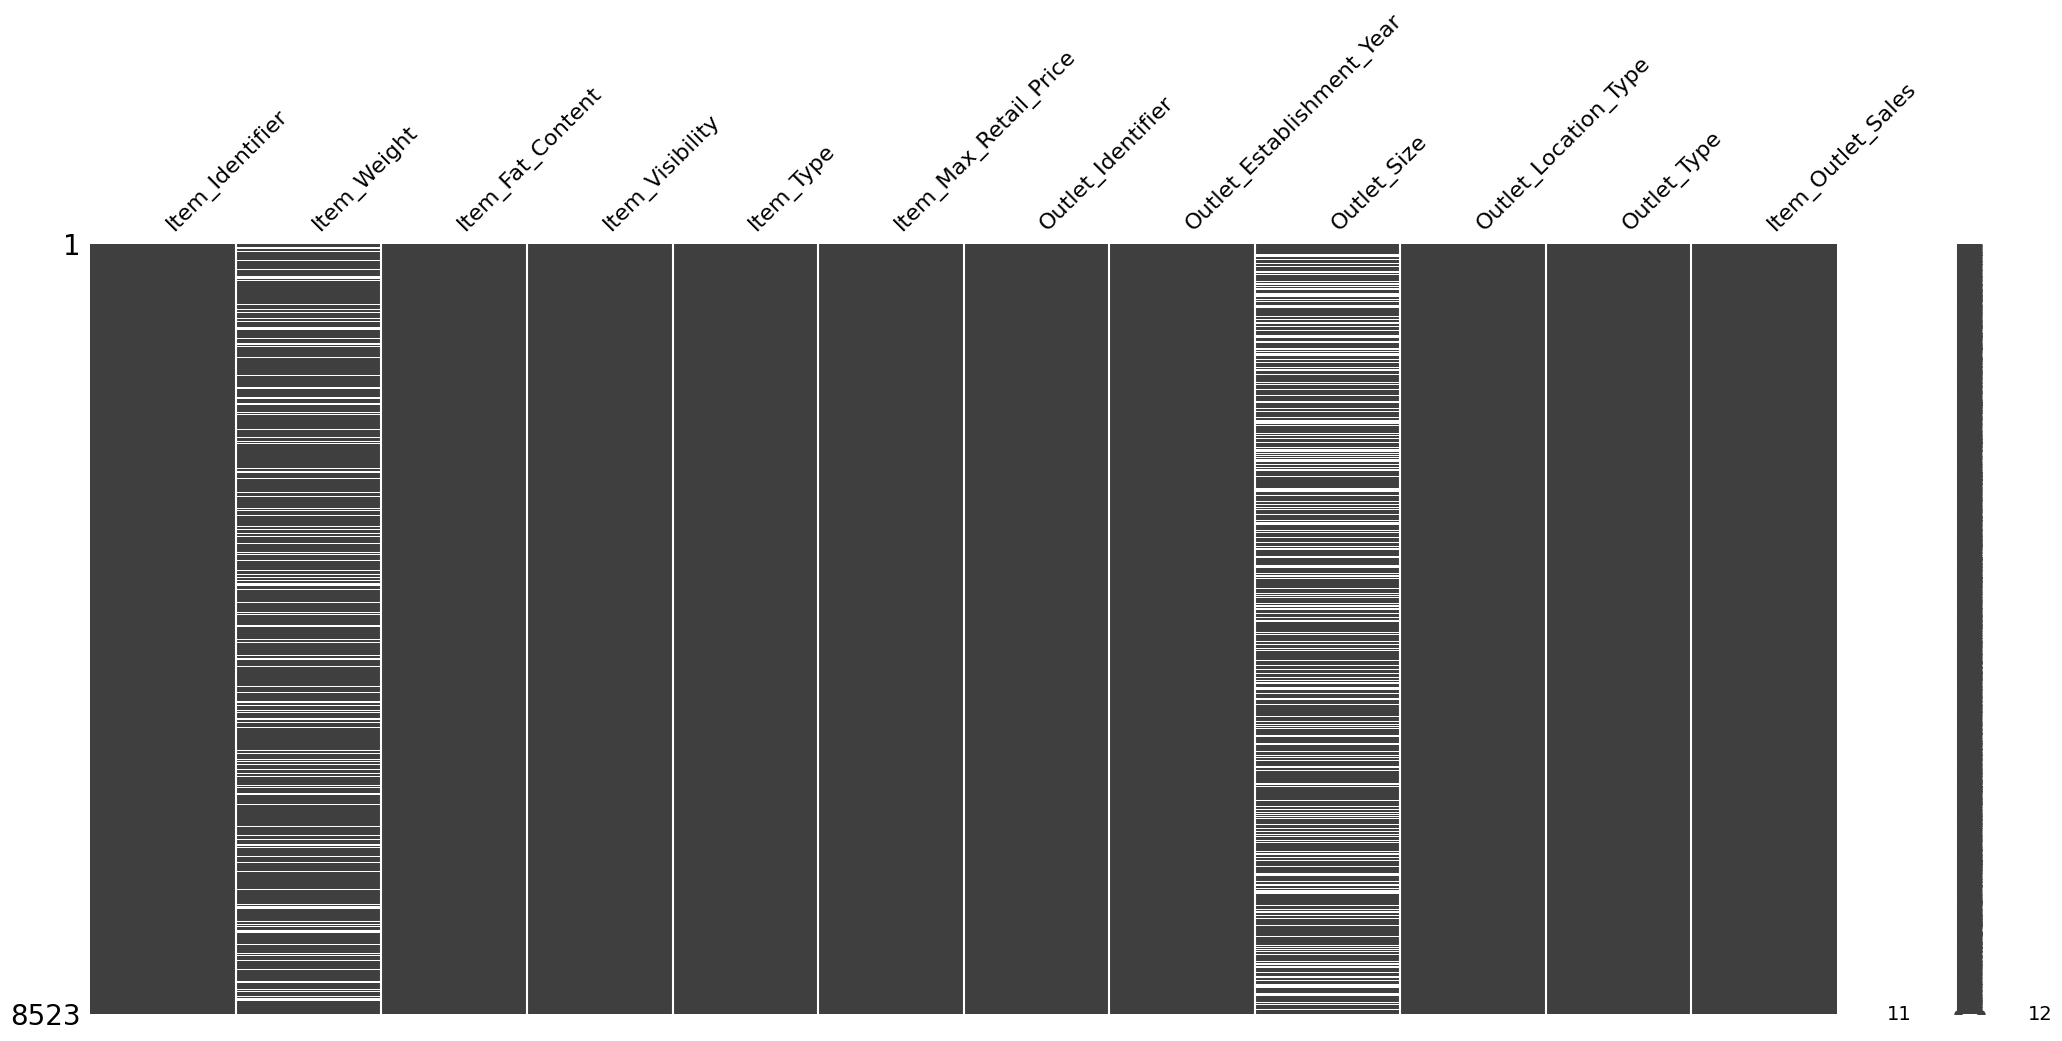

In [180]:
# Visualize the missing values using the missingno package's matrix plot.
import missingno as msno
msno.matrix(df)

#### Address the null values:

- Fill the null values in categorical columns with a placeholder category called MISSING.


In [181]:
# save list of categorical column name. (Hint: select_dtypes)
cat_col= df.select_dtypes(include='object').columns.tolist()
cat_col

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Size',
 'Outlet_Type']

In [182]:
# use the list of cat columns to fill null values with MISSING
df[cat_col] = df[cat_col].fillna('MISSING')
#check the null values
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_Max_Retail_Price,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0



- Fill the null values in numeric columns with a placeholder value of -1



In [183]:
# save list of numeric column names (Hint: select_dtypes)
num_col = df.select_dtypes(include='number').columns.tolist()
num_col

['Item_Weight',
 'Item_Visibility',
 'Item_Max_Retail_Price',
 'Outlet_Identifier',
 'Outlet_Establishment_Year',
 'Outlet_Location_Type',
 'Item_Outlet_Sales']

In [184]:
# use the list of num columns to fill null values with -1
df[num_col] = df[num_col].fillna(-1)
#check the null values
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_Max_Retail_Price,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


- Use either missingno's matrix plot or Pandas to confirm that there are 0 null values remaining.


In [185]:
# Confirm no more nulls using Pandas
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_Max_Retail_Price,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


<Axes: >

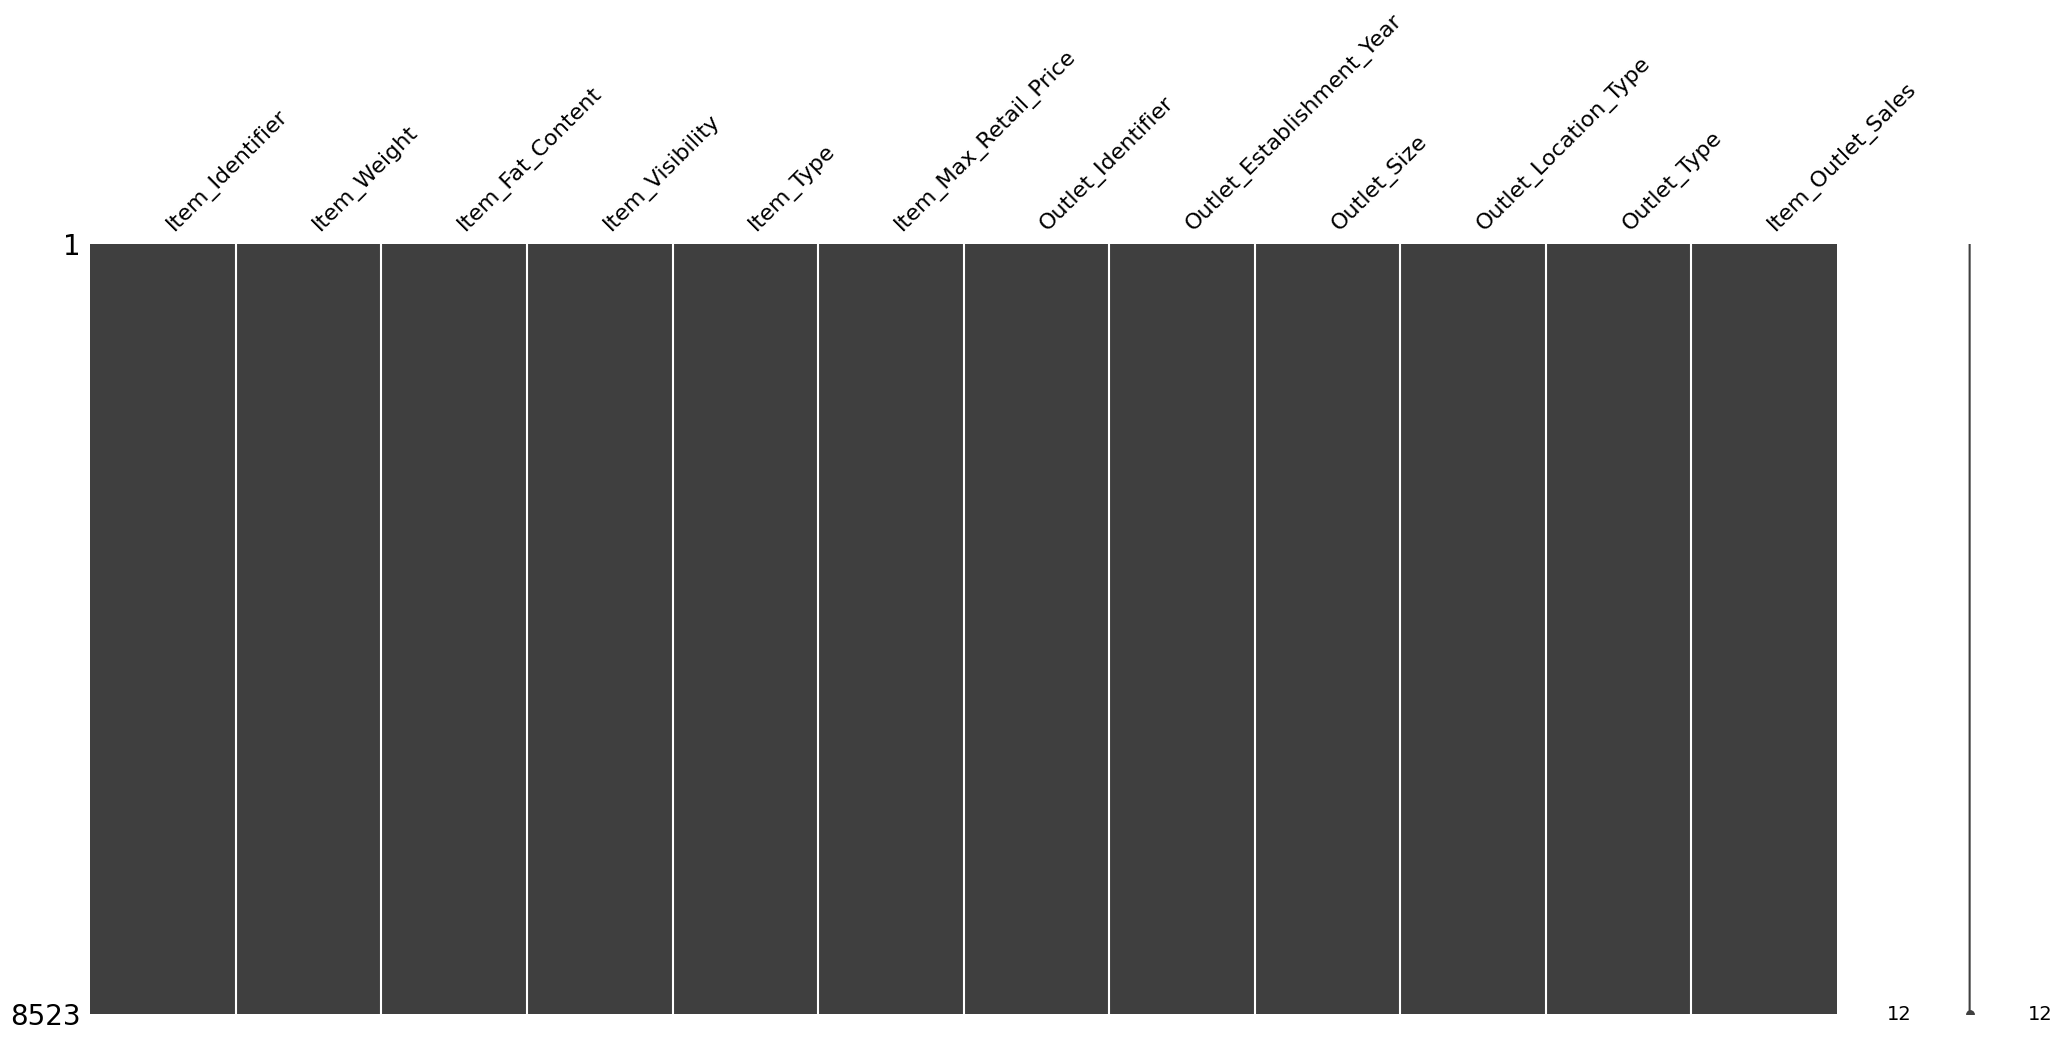

In [186]:
# Confirm no more nulls using using missingno
msno.matrix(df)

## H) Consistent Values

- Check each string column's value counts for inconsistent values.
  - E.g. "Cat" vs "cat", "Y" vs. "Yes"



- Fix/replace the inconsistent values with the values you believe are correct.


- Display the value_counts again to confirm the values are now consistent.
  

In [187]:
# Save a list of object columns (Hint: select_dtypes)
obj_col = df.select_dtypes(include='object').columns.tolist()
obj_col

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Size',
 'Outlet_Type']

In [188]:
# Check the nunique for just the object cols
df[obj_col].nunique()

,0
Item_Identifier,1559
Item_Fat_Content,5
Item_Type,16
Outlet_Size,4
Outlet_Type,4


- Note that out of the 5 categorical columns remaining:
  - 1 columns have 1559 categories (item identifier).
  - the rest 4 columns have a small number of categories.

- We do not want to keep categorical features with so many categories.

In [189]:
# Drop the columns listed above
df.drop(columns=['Item_Identifier'], inplace=True)

### For Each Remaining Categorical Column:

- Display the value counts for the column
- Take a note of any values that are not consistent.
- Remove/fix the inconsistent values
- Confirm by checking the value counts again

In [190]:
# Remake the list of string columns (after dropping previous cols)
obj_col = df.select_dtypes(include='object').columns.tolist()
obj_col
# loop through the list of string columns
for col in obj_col:
  df[col].value_counts()
  # print the value counts for the column
  print(df[col].value_counts())
  # Print an empty line for readability
  print('\n')

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Outlet_Size
Medium     2793
MISSING    2410
Small      2388
High        932
Name: count, dtype: int64


Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64




**'Item_Fat_Content' columns have inconsistent values that need to be addressed**


### Checking & Fixing Consistency: Column 1

In [191]:
# Check for inconsistencies by inspecting the value_counts for Embarked
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [192]:
# Replace "LF" & "low fat" with "Low Fat" ____ "reg" with "Regular"
df['Item_Fat_Content'].replace('LF', 'Low Fat', inplace=True)
df['Item_Fat_Content'].replace('low fat', 'Low Fat', inplace=True)
df['Item_Fat_Content'].replace('reg', 'Regular', inplace=True)
# Check the value counts again to confirm
df['Item_Fat_Content'].value_counts()

/tmp/ipykernel_14666/1722493338.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Fat_Content'].replace('LF', 'Low Fat', inplace=True)
/tmp/ipykernel_14666/1722493338.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


### Checking and Fixing Consistency: Column 2

In [193]:
# # Check for inconsistencies by inspecting the value of outlet size
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
MISSING,2410
Small,2388
High,932


In [194]:
# Replace "High" with "Large"

df['Outlet_Size'].replace('High', 'Large', inplace=True)
# Check the value counts again to confirm
df['Outlet_Size'].value_counts()

/tmp/ipykernel_14666/1783735304.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Outlet_Size'].replace('High', 'Large', inplace=True)


,count
Outlet_Size,
Medium,2793
MISSING,2410
Small,2388
Large,932


### Checking and Fixing Consistency: Column 3


In [195]:
# # Check for inconsistencies by inspecting the value of outlet size
df['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


In [196]:
# Replace 'Grocery Store' with  'Supermarket Type4'

df['Outlet_Type'].replace('Grocery Store', 'Supermarket Type4', inplace=True)
# Check the value counts again to confirm
df['Outlet_Type'].value_counts()

/tmp/ipykernel_14666/3457656053.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Outlet_Type'].replace('Grocery Store', 'Supermarket Type4', inplace=True)


,count
Outlet_Type,
Supermarket Type1,5577
Supermarket Type4,1083
Supermarket Type3,935
Supermarket Type2,928


## I) Save the Final DataFrame to Csv

- Save the cleaned DataFrame to my Google Drive
  - Name the file "Sales_Prediction_clean.csv"


In [197]:
# Save the folder + filename as a variable called fpath
Clean_file_path = '/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week09/Data/Sales_Prediction_clean.csv'

# Use to_csv to save the dataframe using the filename
df.to_csv(Clean_file_path,index=False)

- Confirm the data was saved correctly.

In [198]:
# Read in your new .csv file with Pandas.
df_clean=pd.read_csv(Clean_file_path)
# Display the info summary.
df_clean.info()
# Display the first 5 rows.
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Fat_Content           8523 non-null   object 
 2   Item_Visibility            8523 non-null   float64
 3   Item_Type                  8523 non-null   object 
 4   Item_Max_Retail_Price      8523 non-null   float64
 5   Outlet_Identifier          8523 non-null   int64  
 6   Outlet_Establishment_Year  8523 non-null   int64  
 7   Outlet_Size                8523 non-null   object 
 8   Outlet_Location_Type       8523 non-null   int64  
 9   Outlet_Type                8523 non-null   object 
 10  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 732.6+ KB


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_Max_Retail_Price,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,49,1999,Medium,1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,18,2009,Medium,3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,49,1999,Medium,1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,10,1998,MISSING,3,Supermarket Type4,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,13,1987,Large,3,Supermarket Type1,994.7052


In [200]:
df_clean.describe()

,Item_Weight,Item_Visibility,Item_Max_Retail_Price,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Location_Type,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,10.478936,0.066132,140.992782,29.108765,1997.831867,2.112871,2181.288914
std,6.720742,0.051598,62.275067,13.927648,8.371760,0.812757,1706.499616
min,-1.000000,0.000000,31.290000,10.000000,1985.000000,1.000000,33.290000
25%,6.650000,0.026989,93.826500,17.000000,1987.000000,1.000000,834.247400
50%,11.000000,0.053931,143.012800,27.000000,1999.000000,2.000000,1794.331000
75%,16.000000,0.094585,185.643700,45.000000,2004.000000,3.000000,3101.296400
max,21.350000,0.328391,266.888400,49.000000,2009.000000,3.000000,13086.964800
